In [ ]:
import IPython.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal
from pathlib import Path

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\DataSubmission\2023_04_22")
plt.rcParams['figure.figsize'] = [10, 5]

In [ ]:
#store start and end times in array
df = pd.read_csv(DATA_22 / "20230422_171301.Detections.selections.txt", sep="\t") #tabs are used to seperate columns"
print("number of calls detected: ", len(df))

diff = np.zeros(len(df))
for i in range(len(df)):
    diff[i] = df["End Time (s)"][i] - df["Begin Time (s)"][i]
average_call_length = np.mean(diff)
print("Average call length: ", average_call_length)

number of calls detected:  1262
Average call length:  0.23144205626084713


In [154]:
#Clip wanted audio segment from the original audio file
pad = 0.1
start_t = df["Begin Time (s)"].values - pad
end_t = df["End Time (s)"].values + pad

fn = DATA_22 / "20230422_171301.WAV"
f_s, x = wavfile.read(fn)

call_no = 1
start_sample = int(start_t[call_no] * f_s)
end_sample = int(end_t[call_no] * f_s)

audio_segment = x[start_sample:end_sample]

IPython.display.Audio(audio_segment, rate=f_s)

In [155]:
framelength = 1024
noverlap = int(framelength * 0.8)
window = "hamming"

In [156]:
f, t, fft_frames = signal.stft(audio_segment, f_s, nperseg=framelength, noverlap=noverlap, window=window)

(0.0, 500.0)

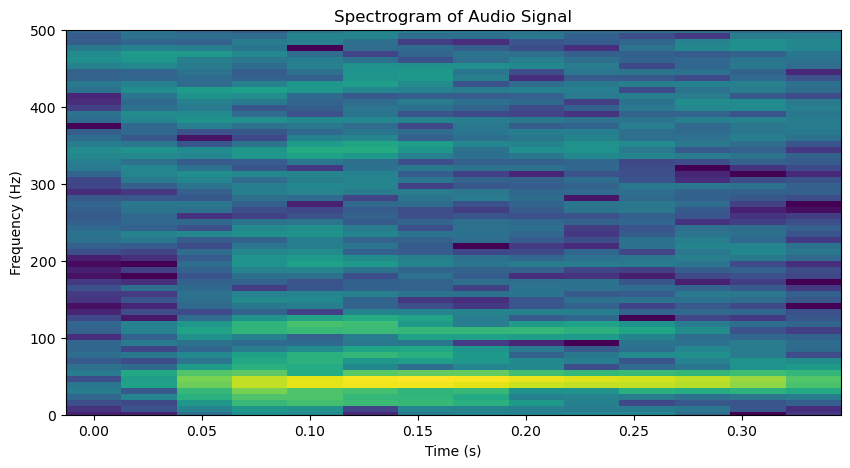

In [157]:
plt.pcolormesh(t, f, np.log(np.abs(fft_frames + 1e-16)), vmin = 0, vmax = np.max(np.log(np.abs(fft_frames + 1e-16))));
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of Audio Signal")
plt.ylim(0, 500)